In [2]:
from keras import utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
from sky import sigma_clip
import matplotlib.gridspec as gridspec
from matplotlib import cm
%pip install photutils
from photutils.psf.matching import TukeyWindow
from photutils.profiles import RadialProfile
taper_2d = TukeyWindow(alpha=0.5)((256, 256))

# To get the images and labels from file
with h5py.File('data/Galaxy10_DECals.h5', 'r') as F:
    images = np.array(F['images'])
    labels = np.array(F['ans'])
    redshift = np.array(F['redshift'])

with h5py.File('data/Galaxy10_Processed.h5', 'r') as F:
    images_processed = np.array(F['images'])

label_indices = labels.copy() 
labels_onehot = utils.to_categorical(labels, 10)

Q = 3.5
alpha = 0.06

label_info = {
0: "Disturbed",
1: "Merging",
2: "Round Smooth",
3: "In-between Round Smooth",
4: "Cigar Shaped Smooth",
5: "Barred Spiral",
6: "Unbarred Tight Spiral",
7: "Unbarred Loose Spiral",
8: "Edge-on without Bulge",
9: "Edge-on with Bulge"
}


Note: you may need to restart the kernel to use updated packages.


Main Image Plotting

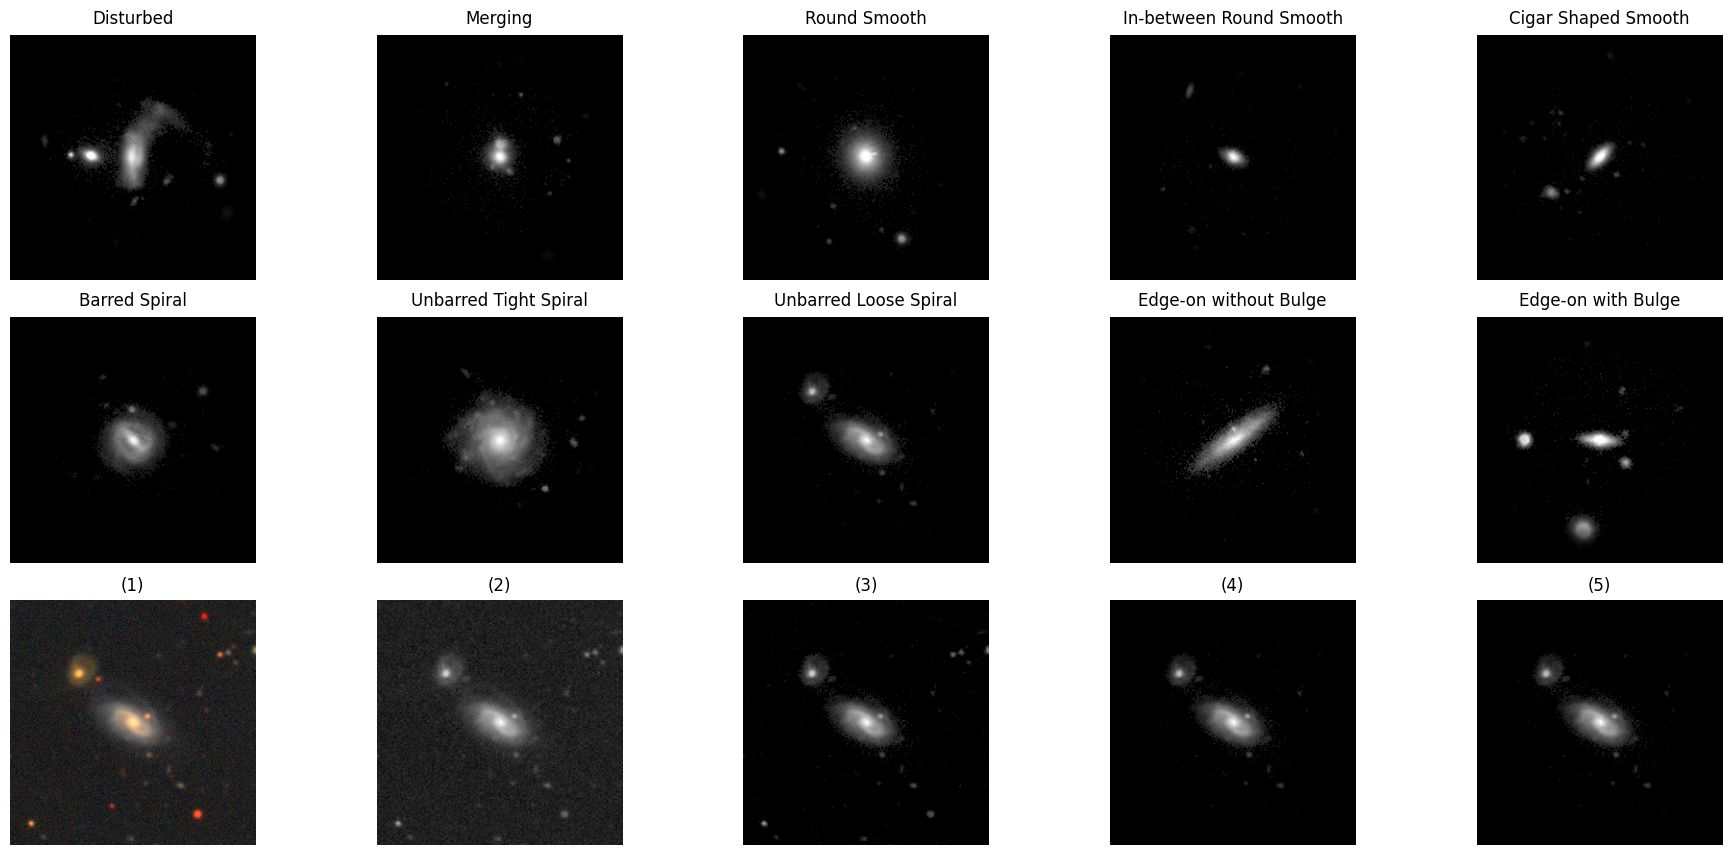

In [3]:
fig = plt.figure(figsize=(20, 9))
gs = gridspec.GridSpec(3, 5, figure=fig)

# --- TOP TWO ROWS: 10 CLASSES ---
for i in range(10):
    row = i // 5
    col = i % 5
    ax = fig.add_subplot(gs[row, col])
    
    # Processing logic
    single_image_idx = np.where(label_indices == i)[0][0]
    image_color = images[single_image_idx]
    
    # Full Physics Pipeline
    raw_flux = image_color[..., 1].astype(np.float32) / 255.0
    mask = sigma_clip(raw_flux, alpha=3, verbose=False)
    sky_level = np.nanmedian(raw_flux[mask])
    sky_std = np.nanstd(raw_flux[mask])
    clean_flux = np.maximum(raw_flux - sky_level, 0)
    clean_flux[clean_flux < (2 * sky_std)] = 0 
    tapered_flux = clean_flux * taper_2d
    final_img = np.arcsinh(alpha * Q * tapered_flux) / Q 
    
    ax.imshow(final_img, cmap='gray')
    ax.set_title(f"{label_info[i]}", fontsize=12, pad=8)
    ax.axis('off')

# --- BOTTOM ROW: PIPELINE EVOLUTION ---
# Select sample for pipeline (Class 7)
sample_idx = np.where(label_indices == 7)[0][0]
img_sample = images[sample_idx]

# Stage 1: RGB
ax1 = fig.add_subplot(gs[2, 0])
ax1.imshow(img_sample)
ax1.set_title("(1)", fontsize=12)
ax1.axis('off')

# Stage 2: r-band
ax2 = fig.add_subplot(gs[2, 1])
r_flux = img_sample[..., 1].astype(np.float32) / 255.0
ax2.imshow(r_flux, cmap='gray')
ax2.set_title("(2)", fontsize=12)
ax2.axis('off')

# Stage 3: Subtraction
ax3 = fig.add_subplot(gs[2, 2])
m = sigma_clip(r_flux, alpha=3, verbose=False)
s_level = np.nanmedian(r_flux[m])
s_std = np.nanstd(r_flux[m])
c_flux = np.maximum(r_flux - s_level, 0)
c_flux[c_flux < (2 * s_std)] = 0
ax3.imshow(c_flux, cmap='gray')
ax3.set_title("(3)", fontsize=12)
ax3.axis('off')

# Stage 4: Tukey
ax4 = fig.add_subplot(gs[2, 3])
t_flux = c_flux * taper_2d
ax4.imshow(t_flux, cmap='gray')
ax4.set_title("(4)", fontsize=12)
ax4.axis('off')

# Stage 5: Arcsinh
ax5 = fig.add_subplot(gs[2, 4])
f_img = np.arcsinh(alpha * Q * t_flux) / Q 
ax5.imshow(f_img, cmap='gray')
ax5.set_title("(5)", fontsize=12)
ax5.axis('off')

# CRUSH THE GAPS:
# wspace and hspace at near-zero removes the white dividers
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.1, hspace=0.15)
plt.savefig('figures/master_preprocessing_figure.png', bbox_inches='tight', dpi=300)
plt.show()

Samples from each bin

C:\Users\marce\AppData\Local\Temp\ipykernel_4432\2126337402.py:1: RuntimeWarning: divide by zero encountered in divide
  x = 7.37 / redshift


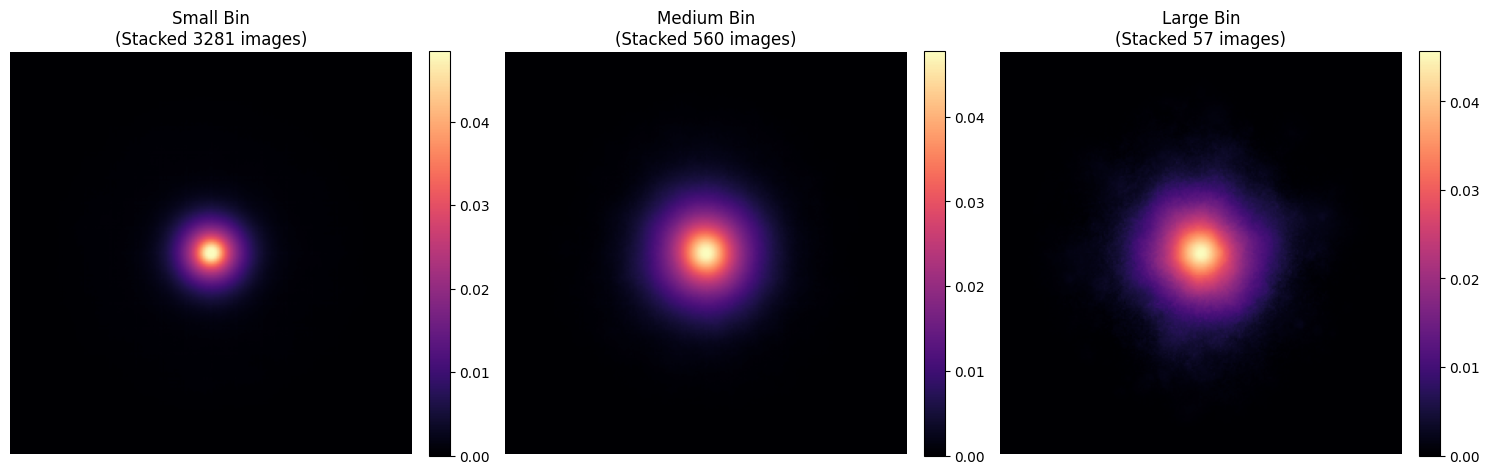

In [8]:
x = 7.37 / redshift

import numpy as np
import matplotlib.pyplot as plt

# 1. Update the function to return ALL matching indices
def get_bin_indices(target_n, n_array, tolerance=5):
    # Find all indices where N is within the tolerance range
    matches = np.where(np.abs(n_array - target_n) < tolerance)[0]
    return matches

# 2. Define your bins and target values
bin_targets = [70, 200, 400]
bin_labels = ['Small', 'Medium', 'Large']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, target, label in zip(axes, bin_targets, bin_labels):
    indices = get_bin_indices(target, x, tolerance=10) # Increased tolerance slightly for better stacking
    
    if len(indices) > 0:
        # Stack images along a new axis and take the mean (or median for outlier rejection)
        # Assuming images_processed is a 3D numpy array [index, height, width]
        stacked_image = np.mean(images_processed[indices], axis=0)
        
        # Plotting as a heatmap
        im = ax.imshow(stacked_image, cmap='magma', origin='lower')
        ax.set_title(f'{label} Bin\n(Stacked {len(indices)} images)')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.set_title(f'{label} Bin (Empty)')
    
    ax.axis('off')

plt.tight_layout()
plt.show()

Redshift distribution

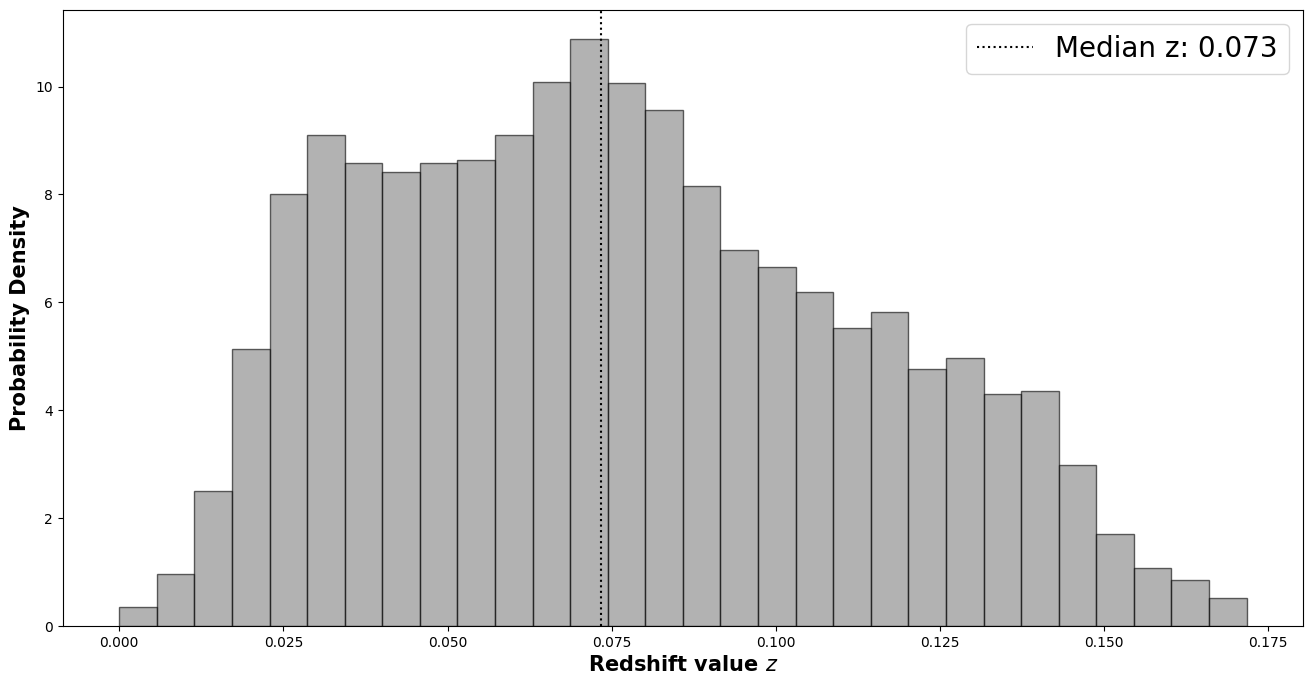

In [ ]:
valid_mask = (redshift > 0.001) & (redshift < 0.25)
z_filtered = redshift[valid_mask]

plt.figure(figsize=(16, 8))

# FIX: range must be a tuple (min, max). 
# We use 0 as min and the 99th percentile as max to exclude extreme outliers.
plot_max = np.percentile(z_filtered, 99)
n, bins, _ = plt.hist(z_filtered, bins=30, range=(0, plot_max), 
                      density=True, color='gray', alpha=0.6, edgecolor = "black")

plt.xlabel(r'Redshift value $z$', fontweight='bold', fontsize = 15)
plt.ylabel('Probability Density', fontweight='bold', fontsize = 15)

# Show the median redshift to help define our 'Average' scale later
median_z = np.median(z_filtered)
plt.axvline(median_z, color='black', linestyle=':', label=f'Median z: {median_z:.3f}')

plt.legend(fontsize = 20)
plt.show()

N Pixel distribution

C:\Users\marce\AppData\Local\Temp\ipykernel_6004\1006097306.py:1: RuntimeWarning: divide by zero encountered in divide
  x = 7.37 / redshift


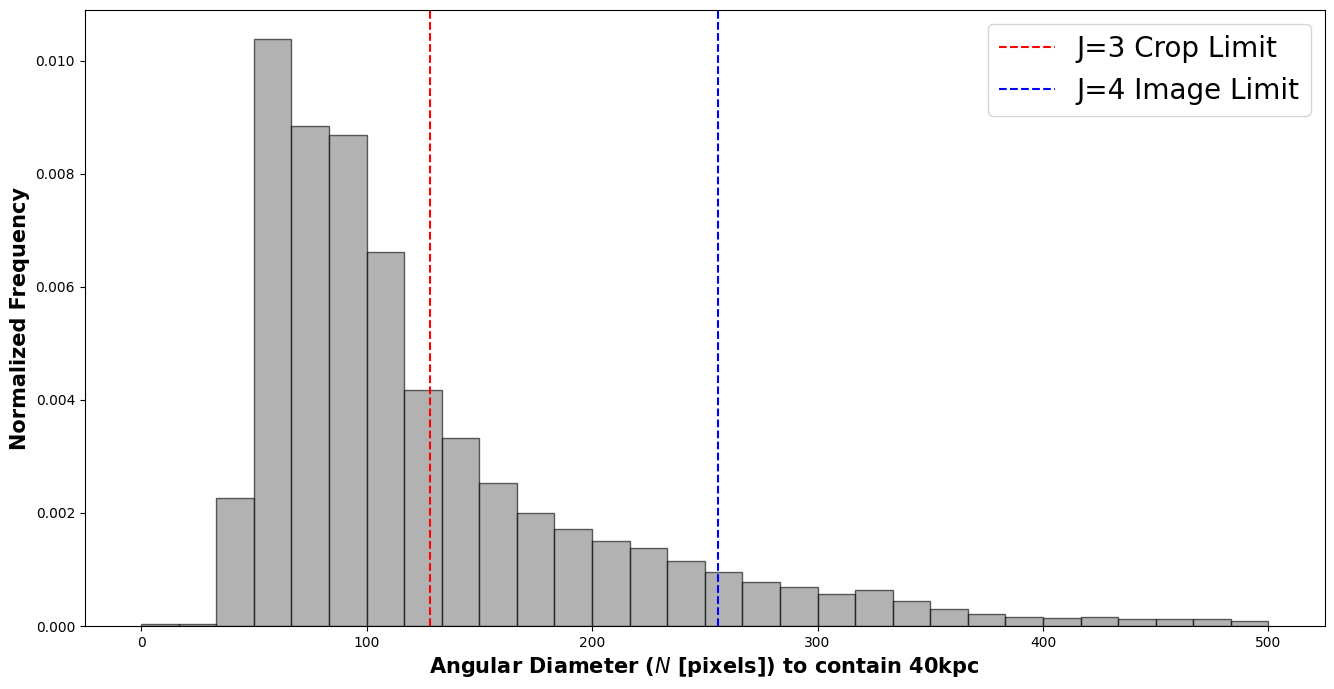

In [ ]:
x = 7.37 / redshift

valid_mask = (redshift > 0.001) & (x < 1000)
x_filtered = x[valid_mask]

plt.figure(figsize=(16, 8))
n, bins, _ = plt.hist(x_filtered, bins=30, range=(0, 500), density=True, color='gray', alpha=0.6, edgecolor='black')

plt.axvline(128, color='red', linestyle='--', label='J=3 Crop Limit')
plt.axvline(256, color='blue', linestyle='--', label='J=4 Image Limit')

plt.xlabel('Angular Diameter ($N$ [pixels]) to contain 40kpc', fontweight='bold', fontsize = 15)
plt.ylabel('Normalized Frequency', fontweight='bold', fontsize = 15)
plt.legend(fontsize=20)
plt.show()

Radial Profile

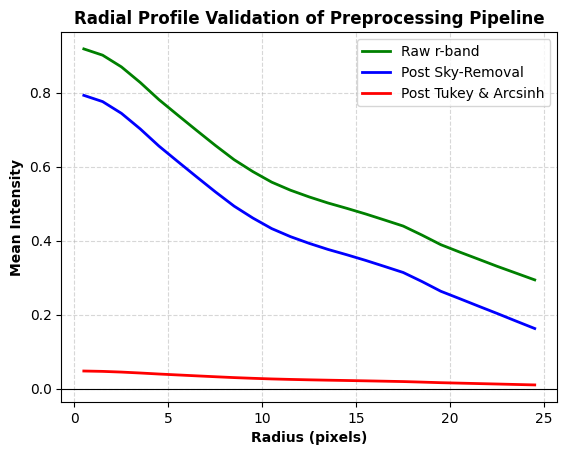

In [5]:
center = (127,127)
edge_radii = np.arange(26)

sample_idx = np.where(label_indices == 7)[0][0]
img_sample = images[sample_idx]

r_flux = img_sample[..., 1].astype(np.float32) / 255.0
rp_r = RadialProfile(r_flux, center, edge_radii, mask=None)

m = sigma_clip(r_flux, alpha=3, verbose=False)
s_level = np.nanmedian(r_flux[m])
s_std = np.nanstd(r_flux[m])
c_flux = np.maximum(r_flux - s_level, 0)
c_flux[c_flux < (2 * s_std)] = 0
rp_sky = RadialProfile(c_flux, center, edge_radii, mask=None)


t_flux = c_flux * taper_2d
f_img = np.arcsinh(alpha * Q * t_flux) / Q 
rp_final = RadialProfile(f_img, center, edge_radii, mask=None)

r_centers = (edge_radii[:-1] + edge_radii[1:]) / 2

# Plot each stage of the pipeline
plt.plot(r_centers, rp_r.profile, label='Raw r-band', color='green', linewidth=2)
plt.plot(r_centers, rp_sky.profile, label='Post Sky-Removal', color='blue', linewidth=2)
plt.plot(r_centers, rp_final.profile, label='Post Tukey & Arcsinh', color='red', linewidth=2)

# Rigor: Add a horizontal line at 0 to show background convergence
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')

# Formatting for Dissertation standards
plt.xlabel('Radius (pixels)', fontweight='bold')
plt.ylabel('Mean Intensity', fontweight='bold')
plt.title('Radial Profile Validation of Preprocessing Pipeline', fontweight='bold')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(frameon=True)

plt.show()

2D Tukey Window

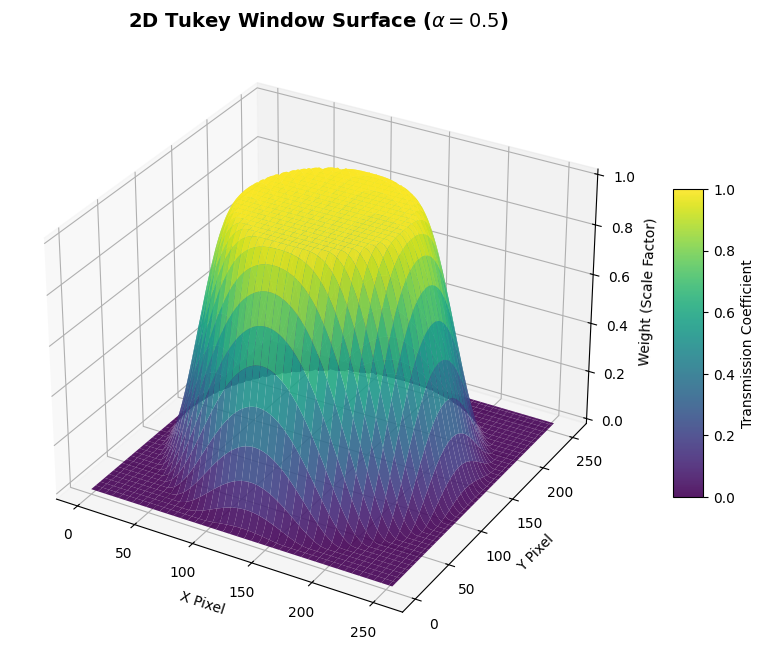

In [ ]:
x = np.linspace(0, 255, 256)
y = np.linspace(0, 255, 256)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
# Assuming 'taper_2d' is your calculated window
surf = ax.plot_surface(X, Y, taper_2d, cmap=cm.viridis,
                       linewidth=0, antialiased=True, alpha=0.9)

# Rigorous Formatting
ax.set_title(r'2D Tukey Window Surface ($\alpha=0.5$)', fontsize=14, fontweight='bold')
ax.set_zlabel('Weight (Scale Factor)')
ax.set_xlabel('X Pixel')
ax.set_ylabel('Y Pixel')

# Add a color bar
fig.colorbar(surf, shrink=0.5, aspect=10, label='Transmission Coefficient')

plt.show()

Map comparison

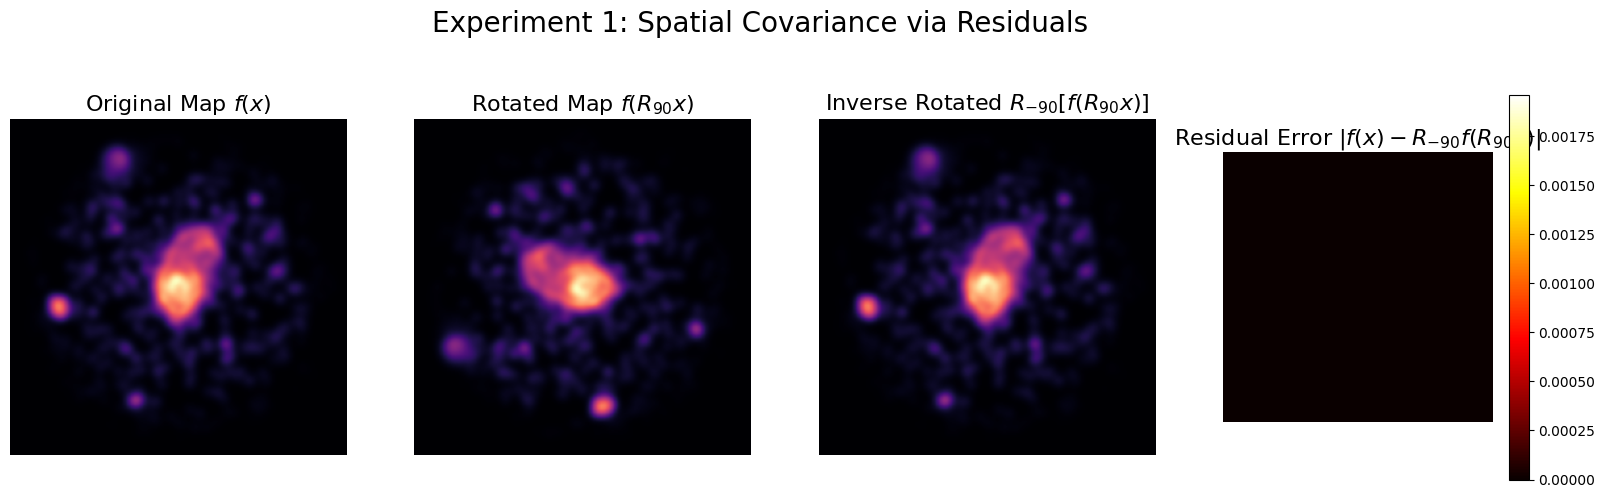

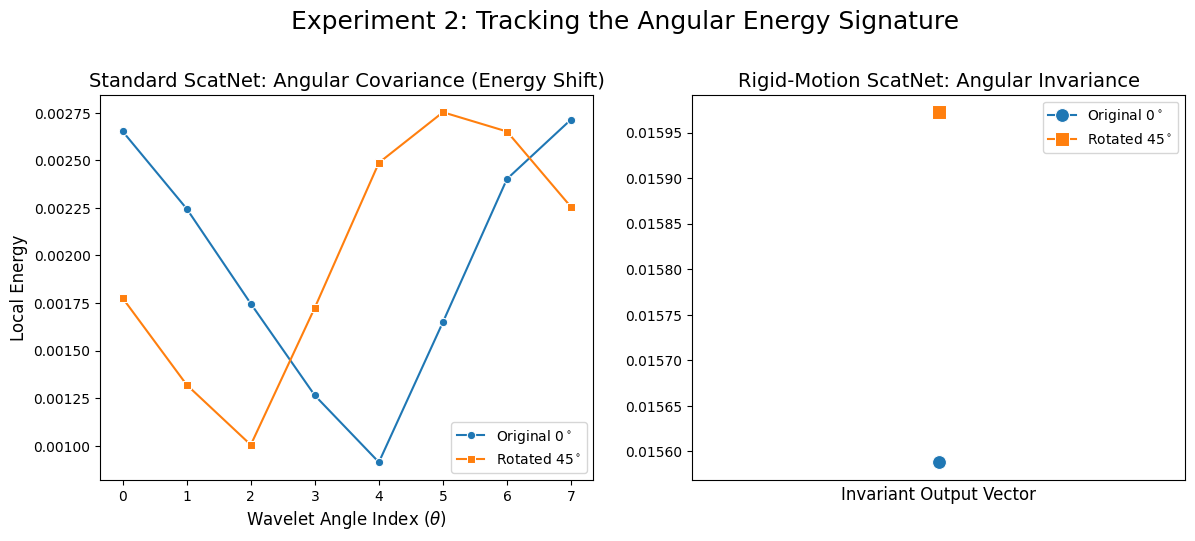

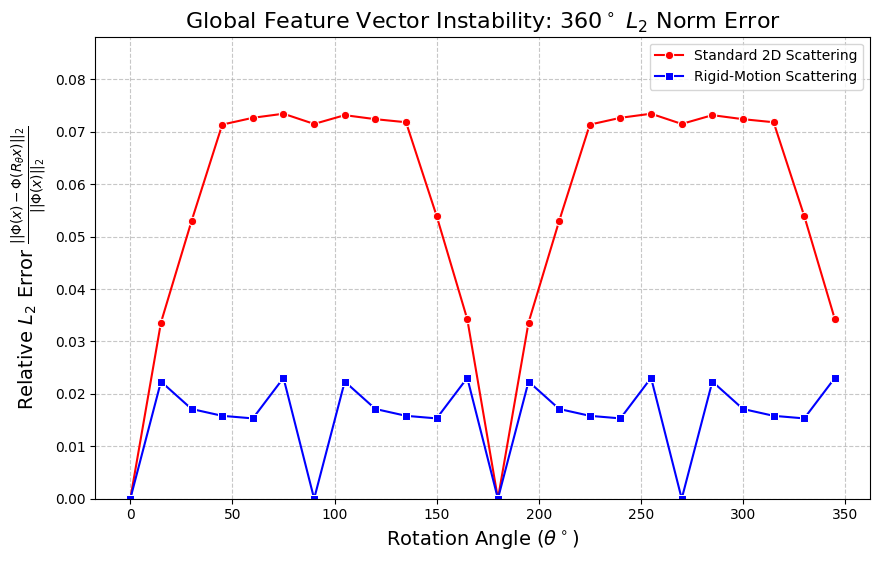

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import rotate
from kymatio.scattering2d.filter_bank import filter_bank
from scipy.fft import ifft2, fft2
import seaborn as sns

# --- 1. SETUP & HYPERPARAMETERS ---
M_input = 256
J = 3 
L = 8 
filters_set = filter_bank(M_input, M_input, J, L=L)
low_pass_gaussian = filters_set['phi']["levels"][0]

# Replace with your actual image array
# img_sample = images_processed[sample_idx] 
img_sample = images_processed[66] 

# --- 2. CORE EXTRACTION FUNCTIONS ---

def get_full_angular_features(image, target_j=1):
    """
    Extracts the un-summed moduli for a specific scale across all L angles.
    This is required to prove angular covariance (the energy shift).
    """
    freq_channel = fft2(image)
    angular_maps = []
    
    current_psi = [f for f in filters_set['psi'] if f['j'] == target_j]
    # Sort by theta to ensure correct order [0 to L-1]
    current_psi = sorted(current_psi, key=lambda x: x['theta'])
    
    for f_dict in current_psi:
        f_freq = f_dict['levels'][0]
        u1_spatial = np.abs(ifft2(freq_channel * f_freq))
        
        # Apply spatial low-pass to the individual modulus
        u1_f = fft2(u1_spatial)
        s1_map = np.real(ifft2(u1_f * low_pass_gaussian))
        angular_maps.append(s1_map)
        
    return np.stack(angular_maps) # Shape: (L, M, M)

def get_feature_vectors(image):
    """
    Extracts the global feature vectors (summed over space) for benchmarking.
    Returns standard (angle-dependent) and rigid (angle-invariant) vectors.
    """
    freq_channel = fft2(image)
    standard_vector = []
    rigid_vector = []
    
    for target_j in range(J):
        current_psi = [f for f in filters_set['psi'] if f['j'] == target_j]
        scale_maps = []
        
        for f_dict in current_psi:
            f_freq = f_dict['levels'][0]
            u1_spatial = np.abs(ifft2(freq_channel * f_freq))
            u1_f = fft2(u1_spatial)
            s1_map = np.real(ifft2(u1_f * low_pass_gaussian))
            
            # Standard feature: global sum of THIS specific angle map
            standard_vector.append(np.sum(s1_map))
            scale_maps.append(s1_map)
            
        # Rigid feature: sum ACROSS angles first, then global spatial sum
        invariant_map = np.sum(np.stack(scale_maps), axis=0)
        rigid_vector.append(np.sum(invariant_map))
        
    return np.array(standard_vector), np.array(rigid_vector)


# --- 3. EXPERIMENT 1: SPATIAL RESIDUAL MAP ---
# Proving: R_{-\theta}[f(R_\theta x)] - f(x) = 0
# We use 90 degrees strictly to avoid scipy bicubic interpolation noise masking the scattering error.

theta_test = 90
img_rot = rotate(img_sample, theta_test, reshape=False, order=1)

# Extract Rigid-Motion Map (Order 1 Invariant Sum at j=1)
map_orig = np.sum(get_full_angular_features(img_sample, target_j=1), axis=0)
map_rot = np.sum(get_full_angular_features(img_rot, target_j=1), axis=0)

# Inverse rotate the map
map_rot_inv = rotate(map_rot, -theta_test, reshape=False, order=1)

# Calculate Residual Error
residual = np.abs(map_orig - map_rot_inv)

fig1, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(map_orig, cmap='magma'); axes[0].set_title(r"Original Map $f(x)$", fontsize=16)
axes[1].imshow(map_rot, cmap='magma'); axes[1].set_title(r"Rotated Map $f(R_{90} x)$", fontsize=16)
axes[2].imshow(map_rot_inv, cmap='magma'); axes[2].set_title(r"Inverse Rotated $R_{-90}[f(R_{90} x)]$", fontsize=16)
img_res = axes[3].imshow(residual, cmap='hot', vmin=0, vmax=np.max(map_orig)*0.2) 
axes[3].set_title(r"Residual Error $|f(x) - R_{-90}f(R_{90}x)|$", fontsize=16)
fig1.colorbar(img_res, ax=axes[3])
for ax in axes: ax.axis('off')
plt.suptitle("Experiment 1: Spatial Covariance via Residuals", fontsize=20, y=1.05)


# --- 4. EXPERIMENT 2: ANGULAR ENERGY SHIFT ---
# Proving: Standard networks shift energy across L; Rigid networks integrate it out.

theta_test_45 = 45 
img_rot_45 = rotate(img_sample, theta_test_45, reshape=False, order=3)

# Get full L-channel arrays for a specific scale
L_maps_orig = get_full_angular_features(img_sample, target_j=2)
L_maps_rot = get_full_angular_features(img_rot_45, target_j=2)

# Find the brightest spatial pixel in the original image's 0-degree map to track
max_y, max_x = np.unravel_index(np.argmax(L_maps_orig[0]), L_maps_orig[0].shape)

# Extract the 1D angular signature at this exact physical location
# (Note: for the rotated image, we must track where that pixel physically moved)
y_center, x_center = M_input // 2, M_input // 2
rad = np.deg2rad(-theta_test_45)
new_x = int((max_x - x_center) * np.cos(rad) - (max_y - y_center) * np.sin(rad) + x_center)
new_y = int((max_x - x_center) * np.sin(rad) + (max_y - y_center) * np.cos(rad) + y_center)
new_x = np.clip(new_x, 0, M_input-1); new_y = np.clip(new_y, 0, M_input-1)

sig_orig = L_maps_orig[:, max_y, max_x]
sig_rot = L_maps_rot[:, new_y, new_x]

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(x=range(L), y=sig_orig, marker='o', label=r'Original $0^\circ$', ax=ax1)
sns.lineplot(x=range(L), y=sig_rot, marker='s', label=r'Rotated $45^\circ$', ax=ax1)
ax1.set_title("Standard ScatNet: Angular Covariance (Energy Shift)", fontsize=14)
ax1.set_xlabel(r"Wavelet Angle Index ($\theta$)", fontsize=12)
ax1.set_ylabel("Local Energy", fontsize=12)

# Rigid Motion Signature (The sum/integration across angles)
sns.lineplot(x=[0], y=[np.sum(sig_orig)], marker='o', markersize=10, label=r'Original $0^\circ$', ax=ax2)
sns.lineplot(x=[0], y=[np.sum(sig_rot)], marker='s', markersize=10, label=r'Rotated $45^\circ$', ax=ax2)
ax2.set_title("Rigid-Motion ScatNet: Angular Invariance", fontsize=14)
ax2.set_xlabel("Invariant Output Vector", fontsize=12)
ax2.set_xticks([])
plt.suptitle("Experiment 2: Tracking the Angular Energy Signature", fontsize=18, y=1.05)


# --- 5. EXPERIMENT 3: 360-DEGREE CONTINUOUS L2 ERROR ---
# Proving: Global feature stability across all orientations.

angles = np.arange(0, 360, 15)
std_errors = []
rigid_errors = []

vec_std_0, vec_rigid_0 = get_feature_vectors(img_sample)

for ang in angles:
    img_ang = rotate(img_sample, ang, reshape=False, order=3)
    vec_std_ang, vec_rigid_ang = get_feature_vectors(img_ang)
    
    # Calculate L2 Distance normalized by the baseline norm
    err_std = np.linalg.norm(vec_std_0 - vec_std_ang) / np.linalg.norm(vec_std_0)
    err_rigid = np.linalg.norm(vec_rigid_0 - vec_rigid_ang) / np.linalg.norm(vec_rigid_0)
    
    std_errors.append(err_std)
    rigid_errors.append(err_rigid)

fig3, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=angles, y=std_errors, marker='o', label='Standard 2D Scattering', color='red')
sns.lineplot(x=angles, y=rigid_errors, marker='s', label='Rigid-Motion Scattering', color='blue')
ax.set_title(r"Global Feature Vector Instability: $360^\circ$ $L_2$ Norm Error", fontsize=16)
ax.set_xlabel(r"Rotation Angle ($\theta^\circ$)", fontsize=14)
ax.set_ylabel(r"Relative $L_2$ Error $\frac{||\Phi(x) - \Phi(R_\theta x)||_2}{||\Phi(x)||_2}$", fontsize=14)
ax.set_ylim(0, max(std_errors)*1.2)
plt.grid(True, which='both', linestyle='--', alpha=0.7)

plt.show()

Uncertainty

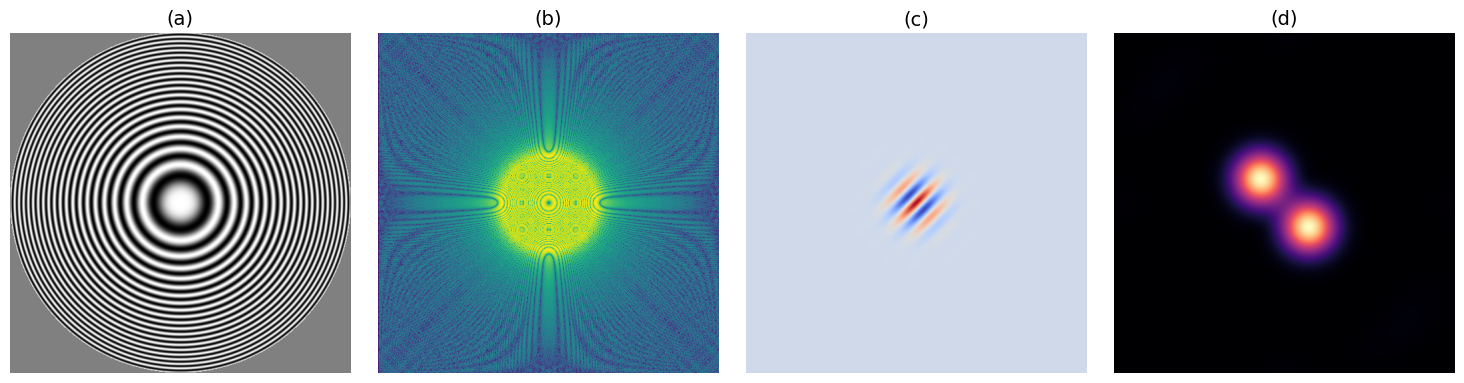

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.fft import fft2, fftshift

# --- 1. Define the 2D Spatial Grid ---
N = 512
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, y)
R2 = X**2 + Y**2

# Apply a circular mask to prevent square boundary artifacts in the FFT
mask = (R2 <= 1.0).astype(float)

# --- 2. Panel A: The Spatial Chirp (Zone Plate) ---
# Frequency increases linearly with distance from the origin
k_chirp = 40  
zone_plate = np.cos(k_chirp * np.pi * R2) * mask

# --- 3. Panel B: Global 2D Fourier Transform ---
# Taking the FFT of the entire image
F_zp = fftshift(fft2(zone_plate))
F_mag = np.log(1 + np.abs(F_zp))

# --- 4. Panel C: The 2D Morlet Wavelet ---
# Bounded in space by sigma, centered at frequency k0, orientation theta
sigma = 0.1
target_frequency = 40 * np.pi * 0.4  # Tuned to target a specific radius of the chirp
theta = np.pi / 4                    # 45 degrees

kx = target_frequency * np.cos(theta)
ky = target_frequency * np.sin(theta)

# The Complex Morlet (Without admissibility correction for visualization)
wavelet = np.exp(1j * (kx * X + ky * Y)) * np.exp(-R2 / (2 * sigma**2))
wavelet_real = np.real(wavelet)

# --- 5. Panel D: The Wavelet Transform Modulus ---
# Convolve the image with the complex wavelet and take the magnitude
# This demonstrates localization in both space and frequency
W_modulus = np.abs(fftconvolve(zone_plate, wavelet, mode='same'))

# --- 6. Rendering the Academic Plot ---
fig, axes = plt.subplots(1, 4, figsize=(15, 8))

# Panel A
ax_a = axes[0]
ax_a.imshow(zone_plate, cmap='gray', extent=[-1, 1, -1, 1])
ax_a.set_title(r"(a)", fontsize=14)
ax_a.set_xlabel("x"); ax_a.set_ylabel("y")
ax_a.axis("off")

# Panel B
ax_b = axes[1]
ax_b.imshow(F_mag, cmap='viridis', extent=[-1, 1, -1, 1])
ax_b.set_title(r"(b)", fontsize=14)
ax_b.set_xlabel(r"$k_x$"); ax_b.set_ylabel(r"$k_y$")
ax_b.axis("off")

# Panel C
ax_c = axes[2]
ax_c.imshow(wavelet_real, cmap='coolwarm', extent=[-1, 1, -1, 1])
ax_c.set_title(r"(c)", fontsize=14)
ax_c.set_xlabel("x"); ax_c.set_ylabel("y")
ax_c.axis("off")

# Panel D
ax_d = axes[3]
ax_d.imshow(W_modulus, cmap='magma', extent=[-1, 1, -1, 1])
ax_d.set_title(r"(d)", fontsize=14)
ax_d.set_xlabel("x"); ax_d.set_ylabel("y")
ax_d.axis("off")

plt.tight_layout(pad=2.0)
plt.axis("off")
plt.show()

Scale justification

C:\Users\marce\AppData\Local\Temp\ipykernel_26368\1072371849.py:6: RuntimeWarning: divide by zero encountered in divide
  res = list(zip(images_processed, 7.37/ redshift))


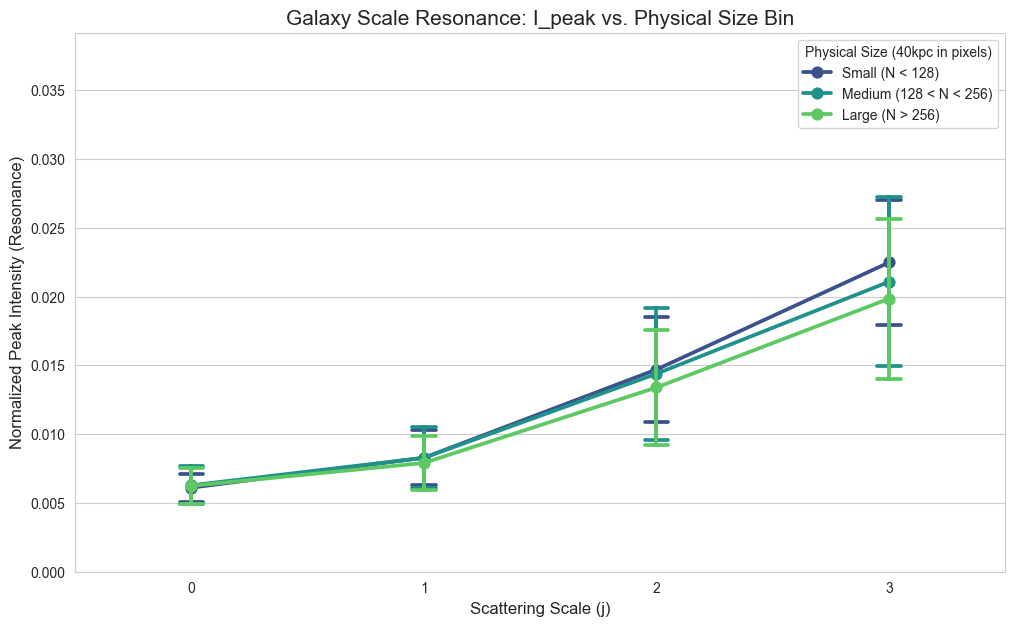

In [ ]:
import pandas as pd
import seaborn as sns
from kymatio.scattering2d.filter_bank import filter_bank
from scipy.fft import ifft2

res = list(zip(images_processed, 7.37/ redshift))


M_input = 256
J = 4 # Number of scales
L = 8 # Number of angles
K = 1 # Number of 1d scales
downscale_factor = 2**J

filters_set = filter_bank(M_input, M_input, J, L=L) # Creates the Morlet wavelets

def extract_scale_peaks(image):
    #normed_image = image / np.max(image)
    freq_channel = np.fft.fft2(image)
    low_pass_gaussian = filters_set['phi']["levels"][0]
    
    peaks = {}
    
    # We must group psi filters by scale j
    for target_j in range(J): # J=4 means j=0,1,2,3
        u1_sum_spatial = np.zeros_like(image, dtype=np.float32)
        
        # Filter psi for only this specific scale
        current_psi = [f for f in filters_set['psi'] if f['j'] == target_j]
        
        for f_dict in current_psi:
            f_freq = f_dict['levels'][0]
            u1_spatial = np.abs(np.fft.ifft2(freq_channel * f_freq))
            u1_sum_spatial += u1_spatial
            
        # Low-pass the sum for this specific scale
        u1_sum_freq = np.fft.fft2(u1_sum_spatial)
        summed_map = np.real(np.fft.ifft2(u1_sum_freq * low_pass_gaussian))
        
        # Extract the Peak Intensity for this scale
        peaks[target_j] = np.max(summed_map)
        
    return peaks

idxA = [i for i, (img, y) in enumerate(res) if y < 128]
idxB = [i for i, (img, y) in enumerate(res) if 128 <= y < 256]
idxC = [i for i, (img, y) in enumerate(res) if y >= 256]

# Randomly sample indices
sampA = np.random.choice(idxA, min(50, len(idxA)), replace=False)
sampB = np.random.choice(idxB, min(50, len(idxB)), replace=False)
sampC = np.random.choice(idxC, min(50, len(idxC)), replace=False)

# Retrieve images for the bins
binA = [images_processed[i] for i in sampA]
binB = [images_processed[i] for i in sampB]
binC = [images_processed[i] for i in sampC]

def gather_bin_data(bin_images, bin_label):
    bin_results = []
    for img in bin_images:
        # Extract peaks using your function
        p_dict = extract_scale_peaks(img)
        # Store for DataFrame
        for j_val, peak_val in p_dict.items():
            bin_results.append({
                'Bin': bin_label,
                'Scale (j)': j_val,
                'Peak Intensity': peak_val
            })
    return bin_results

# 1. Collect data from all bins
all_results = []
all_results.extend(gather_bin_data(binA, 'Small (N < 128)'))
all_results.extend(gather_bin_data(binB, 'Medium (128 < N < 256)'))
all_results.extend(gather_bin_data(binC, 'Large (N > 256)'))

df = pd.DataFrame(all_results)

# 2. Plotting the Resolution Ladder
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Using a pointplot to show the 'Resonance' trend across scales
sns.pointplot(data=df, x='Scale (j)', y='Peak Intensity', hue='Bin', 
              capsize=.1, errorbar='sd', palette='viridis')

plt.title("Galaxy Scale Resonance: I_peak vs. Physical Size Bin", fontsize=15)
plt.ylabel("Normalized Peak Intensity (Resonance)", fontsize=12)
plt.xlabel("Scattering Scale (j)", fontsize=12)
plt.ylim(0, df['Peak Intensity'].max() * 1.1)
plt.legend(title="Physical Size (40kpc in pixels)")
plt.show()